In [37]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy.abc import x, y, s

a_coeffs = [5,3,1,7]#don't use exactly 0 because downstream we will compute relative errors, and 0 would cause division by zero
b_coeffs = [1,4,3,2]

In [38]:
expansion = bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)

In [ ]:
# Choose a fixed s value (e.g., s=0 for the magnet center)
s_fixed = 0.0

def ByiBx(x, y):#analytical definition of By + i*Bx at s=s_fixed
    return By_func(x, y, s_fixed) + 1j * Bx_func(x, y, s_fixed)

dkl = bpmeth.harmonics(ByiBx)
bpmeth.print_harmonics(dkl)
bnian=bpmeth.calc_coeffs(dkl)#bn+i*an
bn=bnian.real[:len(b_coeffs)]
an=bnian.imag[:len(a_coeffs)]

k  l=0                       l=1                       l=2                       
 0    1.0000000,   5.0000000   -0.0000000,   0.0000000   -0.0000000,  -0.0000000
 1    4.0000000,   3.0000000   -0.0000000,   0.0000000   -0.0000000,   0.0000000
-1    0.0000000,   3.0000000    0.0000000,   0.0000000    0.0000000,   0.0000000
 2    1.5000000,   0.5000000   -0.0000000,  -0.0000000   -0.0000000,  -0.0000000
-2    0.0000000,   0.5000000    0.0000000,  -0.0000000    0.0000000,  -0.0000000
 3    0.3333333,   1.1666667    0.0000000,   0.0000000    0.0000000,   0.0000000
-3   -0.0000000,   1.1666667   -0.0000000,   0.0000000   -0.0000000,   0.0000000
 4   -0.0000000,   0.0000000   -0.0000000,   0.0000000   -0.0000000,   0.0000000
-4   -0.0000000,   0.0000000   -0.0000000,   0.0000000   -0.0000000,   0.0000000


In [40]:
import sympy
#evaluate the original coefficients at s=s_fixed
a_coeffs_eval = [sympy.sympify(coeff).subs(s, s_fixed) for coeff in a_coeffs]
b_coeffs_eval = [sympy.sympify(coeff).subs(s, s_fixed) for coeff in b_coeffs]
print("Harmonic analysis results at s=", s_fixed)
print("recovered bn(s=",s_fixed,"):", bn)
print("Original b_coeffs(s):", b_coeffs_eval)
print("recovered an(s=",s_fixed,"):", an)
print("Original a_coeffs(s):", a_coeffs_eval)

Harmonic analysis results at s= 0.0
recovered bn(s= 0.0 ): [1. 4. 3. 2.]
Original b_coeffs(s): [1, 4, 3, 2]
recovered an(s= 0.0 ): [5. 3. 1. 7.]
Original a_coeffs(s): [5, 3, 1, 7]


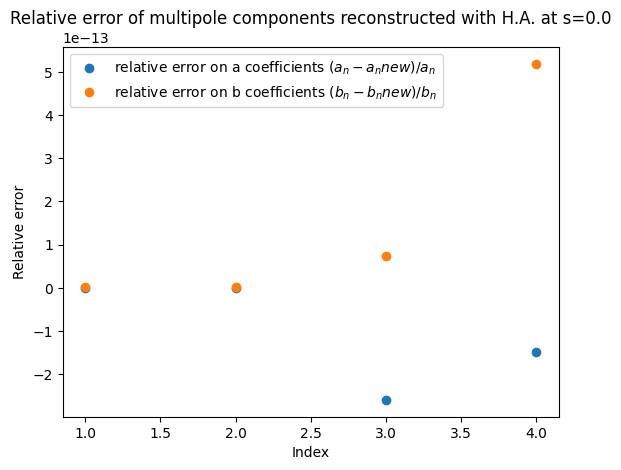

In [ ]:
plt.plot(range(1,len(a_coeffs)+1), (a_coeffs_eval-an)/a_coeffs_eval, 'o', label='relative error on a_n $(a_n - a_nnew)/a_n$')
plt.xlabel('Index')
plt.ylabel('Relative error')
plt.title('Relative error of multipole components reconstructed with H.A. at s=' + str(s_fixed) )
plt.plot(range(1,len(b_coeffs)+1), (b_coeffs_eval-bn)/b_coeffs_eval, 'o', label='relative error on b_n $(b_n - b_nnew)/b_n$')
plt.legend()
plt.show()

In [42]:
#make a fieldmap object
xa= np.linspace(-1,1,101)
ya=np.linspace(-1,1,101)
sa=np.linspace(-1,1,101)
X,Y,S = np.meshgrid(xa, ya, sa)
Bx_ana = Bx_func(X, Y, S)
By_ana = By_func(X, Y, S)
Bs_ana = Bs_func(X, Y, S)
datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_ana.ravel(),
    By_ana.ravel(),
    Bs_ana.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm = bpmeth.fieldmaps.Fieldmap(datafieldmap)

Harmonic analysis along the s axis

In [43]:
sv, recbn, stdrecbn = fm.s_harmonics(order=4, rmin=0.01, rmax=0.5, radius=0.2)

In [44]:
#evaluate the original coefficients along an s axis array

a_coeffs_eval_along_s = np.array([[sympy.sympify(coeff).subs(s, s_val) for coeff in a_coeffs] for s_val in sv])
b_coeffs_eval_along_s = np.array([[sympy.sympify(coeff).subs(s, s_val) for coeff in b_coeffs] for s_val in sv])

Text(0.5, 0, 's')

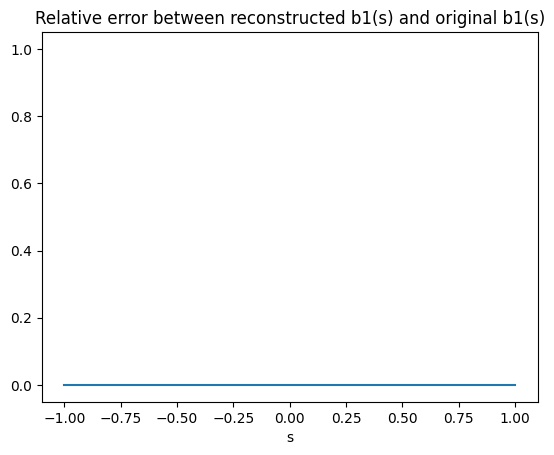

In [45]:
plt.plot(sv, (recbn[:,0]-b_coeffs_eval_along_s[:,0])/b_coeffs_eval_along_s[:,0])
plt.title('Relative error between reconstructed b1(s) and original b1(s)')
plt.fill_between(sv, recbn[:,0]-stdrecbn[:,0], recbn[:,0]+stdrecbn[:,0], alpha=0.2)
plt.xlabel('s')


Text(0.5, 0, 's')

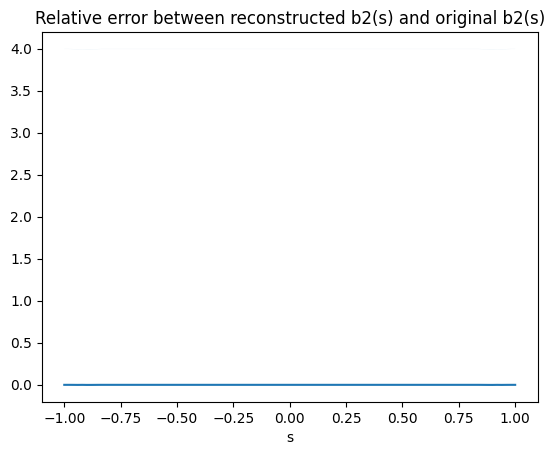

In [46]:
plt.plot(sv, (recbn[:,1]-b_coeffs_eval_along_s[:,1])/(1e-8+b_coeffs_eval_along_s[:,1]))
plt.title('Relative error between reconstructed b2(s) and original b2(s)')
plt.fill_between(sv, recbn[:,1]-stdrecbn[:,1], recbn[:,1]+stdrecbn[:,1], alpha=0.2)
plt.xlabel('s')
